In [ ]:
from langgraph.graph import START,StateGraph,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [5]:
load_dotenv()

True

In [6]:
model=ChatOpenAI()

In [7]:
class LLMState(TypedDict):
    question:str
    answer:str

In [8]:
def llm_qa(state:LLMState) -> LLMState:

    question=state['question']

    prompt=f"answer the fallowing {question}"

    answer=model.invoke(prompt).content

    state['answer']=answer

    return state

In [10]:
llmGraph=StateGraph(LLMState)
llmGraph.add_node('answerthequestion',llm_qa)
llmGraph.add_edge(START,'answerthequestion')
llmGraph.add_edge('answerthequestion',END)

In [11]:
workflow=llmGraph.compile()

In [13]:
intialquestion={'question':'who is the creator of python'}
result=workflow.invoke(intialquestion)

In [15]:
result['answer']

'Guido van Rossum is the creator of Python.'

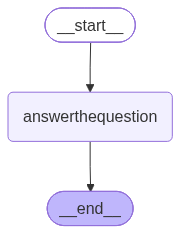

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())